In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"it created: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Mounted at /content/drive
/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-


 [CHECK 1] ResNetFER model initialization ended.

[FORWARD TEST]  (Batch, Channel, H, W): torch.Size([1, 1, 48, 48])
[FORWARD TEST] output shape: torch.Size([1, 7])
 [FORWARD CHECK PASSED]

[CHECK 2 passed]
[DATA CHECK]

 ====== report (ResNet) ======
              precision    recall  f1-score   support

       Angry       0.60      0.49      0.54       799
     Disgust       0.89      0.28      0.42        87
        Fear       0.54      0.35      0.42       820
       Happy       0.75      0.86      0.80      1443
         Sad       0.53      0.46      0.49       966
    Surprise       0.69      0.80      0.74       634
     Neutral       0.51      0.67      0.58       993

    accuracy                           0.62      5742
   macro avg       0.64      0.56      0.57      5742
weighted avg       0.62      0.62      0.61      5742



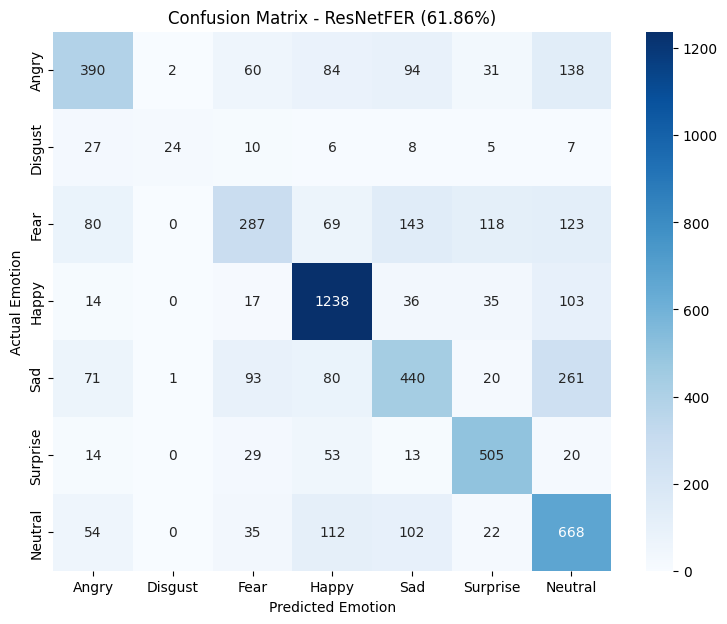

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from dataset import get_dataloaders
from models import ResNetFER

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetFER().to(device)
print(" [CHECK 1] ResNetFER model initialization ended.")

model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 1, 48, 48).to(device)
    dummy_output = model(dummy_input)

    print(f"\n[FORWARD TEST]  (Batch, Channel, H, W): {dummy_input.shape}")
    print(f"[FORWARD TEST] output shape: {dummy_output.shape}")

    assert dummy_output.shape == (1, 7), "Error!"
    print(" [FORWARD CHECK PASSED]\n")
# =====================================================================


best_model_path = "/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/ResNetFER_best.pth"
model.load_state_dict(torch.load(best_model_path))
print("[CHECK 2 passed]")

# 4. test load
_, test_loader = get_dataloaders(
    '/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/fer_dataset/train.csv',
    batch_size=64
)
print("[DATA CHECK]")

all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


print("\n ====== report (ResNet) ======")
print(classification_report(all_labels, all_preds, target_names=emotion_labels))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix - ResNetFER (61.86%)')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

In [ ]:
predictions:

In [16]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from models import ResNetFER

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = ResNetFER().to(device)

best_model_path = "/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/DeepCNN_Advanced_best.pth"
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("🔹 [CHECK] Weights loaded successfully.")


class FERTestDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
        assert 'pixels' in self.df.columns, "test.csv-ში 'pixels' სვეტი არ მოიძებნა"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixels_str = self.df.iloc[idx]['pixels']
        pixels = np.array(pixels_str.split(), dtype=np.float32).reshape(48, 48)
        pixels = pixels / 255.0
        tensor = torch.tensor(pixels).unsqueeze(0)  # shape: (1, 48, 48)
        return tensor


test_csv_path = "/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/fer_dataset/test.csv"
test_dataset = FERTestDataset(test_csv_path)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"🔹 [DATA CHECK] test.csv loaded: {len(test_dataset)} samples .")

# -----------------------------
# 3) Inference
# -----------------------------
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
all_preds = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

print(f"🔹 [INFERENCE DONE]  {len(all_preds)} prediction .")


results_df = pd.DataFrame({'emotion': all_preds})

output_path = "/content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/submission.csv"
results_df.to_csv(output_path, index=False)
print(f"🔹 [SAVED] submission: {output_path}")

print(results_df.head(10))

🔹 [CHECK] Weights loaded successfully.
🔹 [DATA CHECK] test.csv loaded: 7178 samples .
🔹 [INFERENCE DONE]  7178 prediction .
🔹 [SAVED] submission: /content/drive/MyDrive/ML Assignment 4/Facial-Expression-Recognition-Challenge-/submission.csv
   emotion
0        0
1        6
2        0
3        4
4        3
5        3
6        4
7        4
8        4
9        2
